# Shape Analysis: Aligning Two Configurations

**Shape analysis** studies geometric properties of point sets that are invariant under a chosen group of transformations — typically *rigid* (rotation + translation) or *similarity* (rigid + uniform scale). The recurring computational problem is **alignment**: given two configurations $A$ and $B$ of the same object, find the transformation that maps $A$ onto $B$ while minimising the sum of squared distances.

Every algorithm below solves a variant of the same least-squares problem. They differ in:

1. **What is known** — are the point correspondences given, or do we have to discover them?
2. **What is allowed** — rotation only, rotation + translation, or also a scale factor?
3. **How it is solved** — closed-form via SVD, an eigenvalue problem, or alternating iterations.

A summary table at the end places them side-by-side.

## 0. Which problem are you actually solving? — a taxonomy

Before picking an algorithm, answer two questions; they determine everything else.

**Q1 — Do we know the correspondences?** i.e. is it given that point $i$ in $A$ is the *same physical point* as point $i$ in $B$?

- **Yes — correspondences known.** The pairing comes from a feature matcher, a shared index, or synchronised timestamps. The fit is then a **single closed-form** least-squares problem (one SVD or one eigen-decomposition) — no iteration, globally optimal.
- **No — correspondences unknown.** We have two unordered clouds (possibly of different sizes). We must *simultaneously* guess the pairing **and** the transform. This is non-convex, so we alternate (ICP) and only reach a **local** optimum — initialisation matters.

**Q2 — What transform is allowed?** (only relevant once Q1 is settled)

| allowed transform | DoF (3D) | translation? | scale? | closed-form solver |
|---|---|---|---|---|
| rotation only | 3 | no | no | Procrustes / Wahba / Davenport |
| rigid (rotation + translation) | 6 | yes | no | Kabsch |
| similarity (rigid + uniform scale) | 7 | yes | yes | Umeyama |

**Where does noise enter?** Two very different things both get called "noise":

1. **Measurement noise on matched points** — the correspondence is *correct*, but each coordinate is perturbed (sensor noise, triangulation error). Every SVD solver here already handles this: under isotropic Gaussian noise the SVD solution **is** the maximum-likelihood estimate. You do nothing special — the residual $\lVert B - R A\rVert$ is simply non-zero.
2. **Wrong correspondences (outliers / mismatches)** — a matcher paired two points that are *not* the same physical point, or there is no prior pairing at all. Least-squares is **not** robust to this: one gross outlier can swing $R$ arbitrarily. Fixes: wrap the estimator in **RANSAC**, use a **robust kernel** (Huber / Tukey), or — when there is no pairing at all — fall through to **ICP**, which *is* the "estimate the correspondences too" case.

So the decision tree is:

```
correspondences known?
├── yes ──> noise only?       ──> Procrustes / Kabsch / Umeyama   (pick by transform class)
│           outliers present? ──> same solver inside RANSAC / robust loss
└── no  ──> ICP   (alternate: nearest-neighbour association  ↔  Kabsch fit)
                  needs a rough initial guess; converges to a local minimum
```

The rest of this notebook is one section per solver. Each now carries a **by-hand numerical example** small enough to check with a pen — the code cells are only there to confirm the arithmetic scales.


## 1. Orthogonal Procrustes

**Problem.** Given $A, B \in \mathbb{R}^{d \times n}$ (each column is a point; correspondence is by column index), find

$$
R^{\star} \;=\; \arg\min_{R \in O(d)} \; \lVert B - R\,A \rVert_F^2.
$$

**Solution.** Minimising $\lVert B - RA \rVert_F^2$ is equivalent to maximising $\operatorname{tr}(R^\top B A^\top)$. Take $M = B A^\top$, compute its SVD $M = U \Sigma V^\top$, and set

$$
\boxed{\; R^{\star} = U V^\top. \;}
$$

To restrict the answer to a *rotation* (i.e. $\det R = +1$, no reflection), correct the last singular value:

$$
R^{\star} = U \, \mathrm{diag}\!\bigl(1, \ldots, 1, \det(U V^\top)\bigr) \, V^\top.
$$

**Where this shows up — re-orthonormalising a drifted rotation matrix.** Inside an EKF or a hand-rolled pose integrator, $R$ is propagated thousands of times per second by $R \leftarrow R\,\Delta R$. Floating-point round-off pushes $R$ slowly off $SO(3)$ — its singular values drift from 1 and $\det R$ drifts from $+1$. **Project back with Procrustes** by setting $B = R,\ A = I$: SVD of $R = U\Sigma V^\top$, then $\hat R = U\,\mathrm{diag}(1, 1, \det(UV^\top))\,V^\top$ is the closest valid rotation matrix. The same one-liner repairs a 3×3 rotation regressed by a neural network (which has no orthogonality constraint by construction) — used in DeepVO, the rotation head of PoseNet, and most learning-based VO systems.

**Worked example — by hand.** Rotation-only, 2D, two known correspondences. Columns are points:

$$A=\begin{bmatrix}2&0\\0&1\end{bmatrix},\qquad B=\begin{bmatrix}0&-1\\2&0\end{bmatrix}$$

($B$ is $A$ turned $90°$: $p_1=(2,0)\to(0,2)$, $p_2=(0,1)\to(-1,0)$).

1. $M=BA^\top=\begin{bmatrix}0&-1\\2&0\end{bmatrix}\begin{bmatrix}2&0\\0&1\end{bmatrix}=\begin{bmatrix}0&-1\\4&0\end{bmatrix}$.
2. $M^\top M=\begin{bmatrix}16&0\\0&1\end{bmatrix}$ → singular values $\sigma=(4,1)$, and $V=I$ (its eigenvectors are the axes).
3. $U=MV\Sigma^{-1}=\begin{bmatrix}0&-1\\4&0\end{bmatrix}\mathrm{diag}(\tfrac14,\,1)=\begin{bmatrix}0&-1\\1&0\end{bmatrix}$.
4. $R=UV^\top=\begin{bmatrix}0&-1\\1&0\end{bmatrix}$ — exactly the $90°$ rotation; $\det R=+1$, so no reflection fix is needed.

Note $M$ is **not** orthogonal — its columns have lengths $4$ and $1$ — and the SVD is precisely what normalises it back to a rotation. With noisy points $M$ is merely "less orthogonal", and the same $UV^\top$ returns the best-fit rotation.


Procrustes  ‖R̂ - R‖ = 6.899926682599784e-16


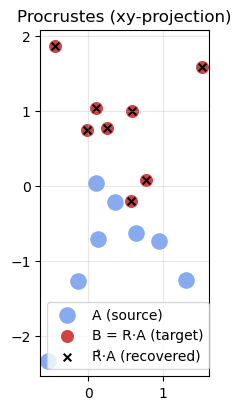

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def orthogonal_procrustes(A, B, proper=True):
    """Return R minimising ‖B - R A‖_F. If proper=True, restrict to SO(d)."""
    M = B @ A.T
    U, _, Vt = np.linalg.svd(M)
    if proper:
        D = np.eye(M.shape[0])
        D[-1, -1] = np.sign(np.linalg.det(U @ Vt))
        return U @ D @ Vt
    return U @ Vt

rng = np.random.default_rng(0)
A = rng.standard_normal((3, 8))
R_true, _ = np.linalg.qr(rng.standard_normal((3, 3)))
if np.linalg.det(R_true) < 0:
    R_true[:, 0] *= -1
B = R_true @ A
R_hat = orthogonal_procrustes(A, B)
print("Procrustes  ‖R̂ - R‖ =", np.linalg.norm(R_hat - R_true))

# Visualise (xy-projection of the 3D point cloud)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
RA = R_hat @ A
ax.scatter(A[0],  A[1],  s=120, c='#88aaee', label='A (source)')
ax.scatter(B[0],  B[1],  s=70,  c='#cc4444', label='B = R·A (target)')
ax.scatter(RA[0], RA[1], s=30,  c='black', marker='x', label='R̂·A (recovered)')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Procrustes (xy-projection)')
plt.show()

## 2. Wahba's problem

**Problem.** Given $N \ge 2$ pairs of unit vectors $\{(\mathbf{a}_i, \mathbf{b}_i)\}_{i=1}^N$ measured in two frames, with non-negative weights $w_i$, find $R \in SO(3)$ minimising

$$
J(R) \;=\; \tfrac12 \sum_{i=1}^{N} w_i \, \lVert \mathbf{b}_i - R\,\mathbf{a}_i \rVert^2.
$$

Standard setting in spacecraft attitude determination: $\mathbf{a}_i$ are reference directions (sun, magnetic field, star catalog) in the inertial frame; $\mathbf{b}_i$ are the same directions measured in the body frame.

**Solution (SVD form).** Form the *attitude profile matrix*

$$
B \;=\; \sum_{i=1}^{N} w_i \, \mathbf{b}_i \mathbf{a}_i^\top \;\in\; \mathbb{R}^{3\times 3},
$$

compute $B = U\Sigma V^\top$, and set

$$
\boxed{\; R^{\star} \;=\; U \, \mathrm{diag}\!\bigl(1, 1, \det(U)\det(V)\bigr) \, V^\top. \;}
$$

The $\det$ correction enforces $\det R^{\star} = +1$. Without it, SVD might return a reflection that achieves the same Frobenius cost.

**Where this shows up — bootstrap attitude for a UAV / quadcopter on the ground.** Before take-off, the IMU is at rest. The accelerometer reads gravity $\mathbf{a}_1^{\,W} = (0, 0, -g)$ in the world frame, the magnetometer reads the local Earth field $\mathbf{a}_2^{\,W}$ (from the WMM model and the GPS-derived location). The same two physical directions, *measured* in the body frame, give $\mathbf{b}_1, \mathbf{b}_2$. Solving Wahba's problem with $N=2$ returns the world-to-body rotation — the **initial attitude** the EKF needs at boot. PX4 and ArduPilot run this exact step (the "MAG initialised" pre-arm log line) before the gyro starts integrating; the same method initialises CubeSats from sun-sensor + magnetometer measurements once on orbit.

**Worked example — by hand (TRIAD, $N=2$).** Two reference directions in the world frame and their body-frame measurements (unit vectors):

$$\mathbf a_1=(1,0,0),\ \mathbf a_2=(0,1,0);\qquad \mathbf b_1=(0,1,0),\ \mathbf b_2=(-1,0,0).$$

For exactly two vectors the pen-and-paper solver is **TRIAD**: build a right-handed triad from each pair and read off $R$.

- Reference triad: $r_1=\mathbf a_1=(1,0,0)$, $\;r_2=\dfrac{\mathbf a_1\times\mathbf a_2}{\lVert\cdot\rVert}=(0,0,1)$, $\;r_3=r_1\times r_2=(0,-1,0)$.
- Body triad: $s_1=\mathbf b_1=(0,1,0)$, $\;s_2=\dfrac{\mathbf b_1\times\mathbf b_2}{\lVert\cdot\rVert}=(0,0,1)$, $\;s_3=s_1\times s_2=(1,0,0)$.

Stack each triad as columns, $M_{\text{ref}}=[\,r_1\ r_2\ r_3\,]$ and $M_{\text{body}}=[\,s_1\ s_2\ s_3\,]$; then

$$R=M_{\text{body}}\,M_{\text{ref}}^\top=\begin{bmatrix}0&-1&0\\1&0&0\\0&0&1\end{bmatrix}=R_z(90°).$$

Check: $R\mathbf a_1=(0,1,0)=\mathbf b_1$ ✓ and $R\mathbf a_2=(-1,0,0)=\mathbf b_2$ ✓. The SVD profile-matrix form in the code returns the identical $R$; TRIAD is just the hand-friendly $N=2$ special case.


Wahba       ‖R̂ - R‖ = 7.385278330912554e-16


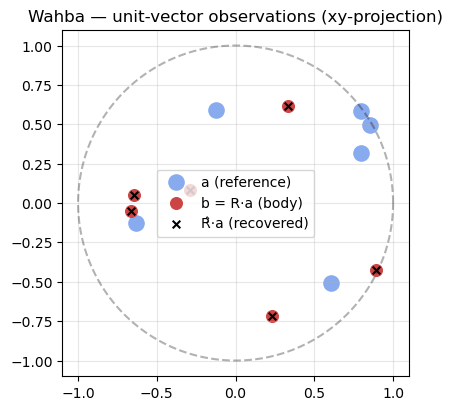

In [2]:
def wahba_svd(a, b, w=None):
    """a, b: (N, 3) unit vectors. Returns R ∈ SO(3)."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    if w is None:
        w = np.ones(len(a))
    B = (w[:, None] * b).T @ a              # 3x3 attitude profile
    U, _, Vt = np.linalg.svd(B)
    d = np.linalg.det(U) * np.linalg.det(Vt)
    return U @ np.diag([1.0, 1.0, d]) @ Vt

a = rng.standard_normal((6, 3))
a /= np.linalg.norm(a, axis=1, keepdims=True)
b = a @ R_true.T
R_hat = wahba_svd(a, b)
print("Wahba       ‖R̂ - R‖ =", np.linalg.norm(R_hat - R_true))

# Project the unit-vector observations onto the xy-plane (the dashed unit circle
# is what they would lie on if all vectors were equatorial).
fig, ax = plt.subplots(figsize=(4.5, 4.5))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
ra = a @ R_hat.T
ax.scatter(a[:, 0],  a[:, 1],  s=120, c='#88aaee', label='a (reference)')
ax.scatter(b[:, 0],  b[:, 1],  s=70,  c='#cc4444', label='b = R·a (body)')
ax.scatter(ra[:, 0], ra[:, 1], s=30,  c='black', marker='x', label='R̂·a (recovered)')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Wahba — unit-vector observations (xy-projection)')
plt.show()

## 3. Davenport's q-method and QUEST

Solves the *same* problem as Wahba's, but parameterises the rotation as a unit quaternion $q \in S^3$. This recasts the optimisation as an eigenvalue problem and avoids the SVD's $\det$ correction — the result lives natively on the quaternion sphere.

Build the same profile matrix $B = \sum_i w_i \mathbf{b}_i \mathbf{a}_i^\top$ and then

$$
S = B + B^\top, \qquad \sigma = \operatorname{tr} B, \qquad \mathbf{z} = \begin{bmatrix} B_{23} - B_{32} \\ B_{31} - B_{13} \\ B_{12} - B_{21} \end{bmatrix}.
$$

**Davenport's K matrix:**

$$
K \;=\; \begin{bmatrix} S - \sigma I_3 & \mathbf{z} \\ \mathbf{z}^\top & \sigma \end{bmatrix} \;\in\; \mathbb{R}^{4\times 4}.
$$

**q-method.** The optimal quaternion is the eigenvector corresponding to the *largest* eigenvalue:

$$
\boxed{\; K\, q^{\star} \;=\; \lambda_{\max}\, q^{\star}. \;}
$$

The minimum cost satisfies $J(R^{\star}) = \sum_i w_i - \lambda_{\max}$.

**QUEST.** Identical formulation, but instead of a full eigendecomposition QUEST solves the secular equation $\det(K - \lambda I) = 0$ for $\lambda_{\max}$ via Newton's method (1–2 iterations starting from $\lambda_0 = \sum_i w_i$), then recovers $q^{\star}$ from the linear system $(K - \lambda_{\max} I)\,q = 0$. This is what made it fast enough for 1980s flight computers.

**Where this shows up — flight-grade attitude estimation, spacecraft and UAV.** NASA Magsat (1979) onwards every spacecraft has used QUEST to convert star-tracker observations (5–10 catalog matches per frame at 10 Hz) into an attitude quaternion onboard — a full SVD or `eigh` is a luxury when you have 16 KB of RTOS memory and a hard real-time deadline. The same algorithm appears today inside PX4's EKF2 and ArduPilot's attitude initialiser: at boot, the autopilot uses the resting accelerometer (gravity) and magnetometer (B-field) as two Wahba observations and runs QUEST to seed the quaternion state of the EKF on a 168 MHz STM32F4. The output quaternion goes straight to the controller without ever materialising a $3\times 3$ rotation matrix.

**Worked example — by hand (same data through Davenport's $K$).** Attitude profile

$$B=\mathbf b_1\mathbf a_1^\top+\mathbf b_2\mathbf a_2^\top=\begin{bmatrix}0&-1&0\\1&0&0\\0&0&0\end{bmatrix}.$$

Then $S=B+B^\top=0$, $\;\sigma=\operatorname{tr}B=0$, and $\;\mathbf z=(B_{23}-B_{32},\,B_{31}-B_{13},\,B_{12}-B_{21})=(0,0,-2)$. So

$$K=\begin{bmatrix}S-\sigma I&\mathbf z\\[2pt]\mathbf z^\top&\sigma\end{bmatrix}=\begin{bmatrix}0&0&0&0\\0&0&0&0\\0&0&0&-2\\0&0&-2&0\end{bmatrix}.$$

Only the $\{3,4\}$ block $\begin{bmatrix}0&-2\\-2&0\end{bmatrix}$ is non-trivial; its eigenvalues are $\pm2$, so $\lambda_{\max}=2$ with eigenvector — the optimal quaternion, ordered $(q_x,q_y,q_z,q_w)$ —

$$q^\star=\bigl(0,\;0,\;\tfrac{1}{\sqrt2},\;-\tfrac{1}{\sqrt2}\bigr).$$

Converting (the code uses the passive convention, $R=\texttt{quat\_to\_R}(q)^\top$) gives back $R_z(90°)$. The minimum cost is $\sum_i w_i-\lambda_{\max}=2-2=0$, confirming an exact fit.


In [3]:
def davenport_q_method(a, b, w=None):
    """Optimal quaternion (qx, qy, qz, qw) for Wahba's problem."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    if w is None:
        w = np.ones(len(a))
    B = (w[:, None] * b).T @ a
    S = B + B.T
    sigma = np.trace(B)
    z = np.array([B[1, 2] - B[2, 1], B[2, 0] - B[0, 2], B[0, 1] - B[1, 0]])
    K = np.zeros((4, 4))
    K[:3, :3] = S - sigma * np.eye(3)
    K[:3,  3] = z
    K[ 3, :3] = z
    K[ 3,  3] = sigma
    eigvals, eigvecs = np.linalg.eigh(K)
    return eigvecs[:, np.argmax(eigvals)]

def quat_to_R(q):
    """Active rotation matrix from quaternion q = (qx, qy, qz, qw)."""
    qx, qy, qz, qw = q
    return np.array([
        [1 - 2*(qy*qy + qz*qz),   2*(qx*qy - qz*qw),   2*(qx*qz + qy*qw)],
        [    2*(qx*qy + qz*qw), 1 - 2*(qx*qx + qz*qz),   2*(qy*qz - qx*qw)],
        [    2*(qx*qz - qy*qw),   2*(qy*qz + qx*qw), 1 - 2*(qx*qx + qy*qy)],
    ])

q_hat = davenport_q_method(a, b)
# Davenport's K is derived in the *passive* (frame-rotation) convention,
# so the active rotation matrix is the transpose of quat_to_R(q).
R_hat = quat_to_R(q_hat).T
print("q-method    ‖R̂ - R‖ =", np.linalg.norm(R_hat - R_true))

q-method    ‖R̂ - R‖ = 1.5072580941561347e-15


## 4. Kabsch algorithm

**Problem.** Same math as orthogonal Procrustes restricted to $d = 3$ and to *rigid* (rotation + translation) transforms. Given correspondence-paired point clouds $P, Q \in \mathbb{R}^{n\times 3}$,

$$
(R^{\star}, \mathbf{t}^{\star}) \;=\; \arg\min_{R \in SO(3),\, \mathbf{t} \in \mathbb{R}^3} \sum_{i=1}^{n} \lVert \mathbf{q}_i - (R\,\mathbf{p}_i + \mathbf{t}) \rVert^2.
$$

**Solution.** The optimal translation is determined once $R$ is known: $\mathbf{t}^{\star} = \bar{\mathbf{q}} - R^{\star} \bar{\mathbf{p}}$. Substituting reduces the problem to centred Procrustes:

1. $\bar{\mathbf{p}} = \tfrac{1}{n}\sum \mathbf{p}_i,\quad \bar{\mathbf{q}} = \tfrac{1}{n}\sum \mathbf{q}_i$
2. $H = \tilde P^\top \tilde Q$ with $\tilde P = P - \bar{\mathbf{p}},\; \tilde Q = Q - \bar{\mathbf{q}}$
3. SVD $H = U \Sigma V^\top$
4. $d = \det(V U^\top)$, $\;D = \mathrm{diag}(1, 1, d)$
5. $\boxed{\; R^{\star} = V D U^\top, \qquad \mathbf{t}^{\star} = \bar{\mathbf{q}} - R^{\star} \bar{\mathbf{p}}. \;}$

The workhorse for any "rigid alignment with known correspondences" problem.

**Where this shows up — loop closure in RGB-D / stereo SLAM.** When the robot revisits a place, the front end (ORB, SIFT, SuperPoint, …) matches features between the current keyframe and a candidate past keyframe. Each match gives a 3D position in *both* keyframes — depth from the RGB-D sensor (Kinect, RealSense, iPhone LiDAR) or from stereo triangulation. **Kabsch on the matched 3D-3D pairs returns the relative pose between the two keyframes**, which becomes the loop-closure constraint added to the pose graph and then smoothed by g2o / GTSAM. The same routine is the rigid registration used in AprilTag-bundle calibration and in visual fiducial-based gripper / hand-eye sanity checks.

**Worked example — by hand (rigid, 3D, four correspondences).** Rows are points. Source (already centred, $\bar{\mathbf p}=0$) and target:

$$P=\begin{bmatrix}1&0&0\\-1&0&0\\0&2&0\\0&-2&0\end{bmatrix},\qquad Q=\begin{bmatrix}5&6&0\\5&4&0\\3&5&0\\7&5&0\end{bmatrix}$$

($Q$ was built as $q_i=R_z(90°)\,p_i+\mathbf t$ with $\mathbf t=(5,5,0)$).

1. Centroids: $\bar{\mathbf p}=(0,0,0)$, $\;\bar{\mathbf q}=(5,5,0)$.
2. Centre the target: $\tilde Q=Q-\bar{\mathbf q}=\{(0,1,0),(0,-1,0),(-2,0,0),(2,0,0)\}$.
3. $H=\tilde P^\top\tilde Q=\sum_i \tilde p_i\,\tilde q_i^\top=\begin{bmatrix}0&2&0\\-8&0&0\\0&0&0\end{bmatrix}$ (singular values $8,2,0$).
4. SVD $\Rightarrow R=VDU^\top=\begin{bmatrix}0&-1&0\\1&0&0\\0&0&1\end{bmatrix}$; $\det=+1$, so $D=I$ (no reflection).
5. $\mathbf t=\bar{\mathbf q}-R\,\bar{\mathbf p}=(5,5,0)$. ✓

Translation drops out by centring; the whole rigid problem is one $3\times3$ SVD.


Kabsch      ‖R̂ - R‖ = 6.933340566559918e-16   ‖t̂ - t‖ = 2.737127597257086e-16


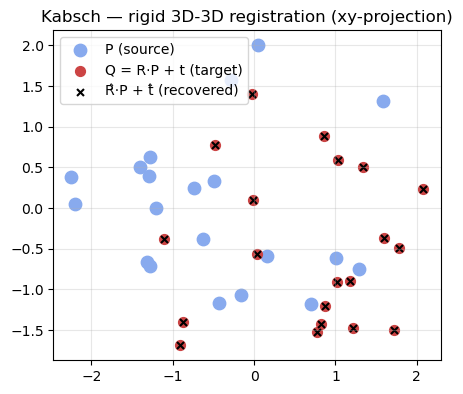

In [4]:
def kabsch(P, Q):
    """P, Q: (N, 3) corresponding rows. Returns R ∈ SO(3), t with Q ≈ P @ R.T + t."""
    p_bar = P.mean(axis=0)
    q_bar = Q.mean(axis=0)
    H = (P - p_bar).T @ (Q - q_bar)
    U, _, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1.0, 1.0, d])
    R = Vt.T @ D @ U.T
    t = q_bar - R @ p_bar
    return R, t

P = rng.standard_normal((20, 3))
t_true = rng.standard_normal(3)
Q = P @ R_true.T + t_true
R_hat, t_hat = kabsch(P, Q)
print("Kabsch      ‖R̂ - R‖ =", np.linalg.norm(R_hat - R_true),
      "  ‖t̂ - t‖ =", np.linalg.norm(t_hat - t_true))

fig, ax = plt.subplots(figsize=(5, 5))
Pt = P @ R_hat.T + t_hat
ax.scatter(P[:, 0],  P[:, 1],  s=80, c='#88aaee', label='P (source)')
ax.scatter(Q[:, 0],  Q[:, 1],  s=50, c='#cc4444', label='Q = R·P + t (target)')
ax.scatter(Pt[:, 0], Pt[:, 1], s=25, c='black', marker='x', label='R̂·P + t̂ (recovered)')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Kabsch — rigid 3D-3D registration (xy-projection)')
plt.show()

## 5. Umeyama algorithm

**Problem.** Extends Kabsch by also estimating a positive uniform scale $s$:

$$
(s^{\star}, R^{\star}, \mathbf{t}^{\star}) \;=\; \arg\min_{s>0,\, R \in SO(d),\, \mathbf{t}} \sum_{i=1}^{n} \lVert \mathbf{q}_i - (s\,R\,\mathbf{p}_i + \mathbf{t}) \rVert^2.
$$

**Solution.** Same centring trick as Kabsch, plus a scale step:

- $\Sigma_{pq} = \tfrac{1}{n} \sum_i (\mathbf{q}_i - \bar{\mathbf{q}})(\mathbf{p}_i - \bar{\mathbf{p}})^\top$
- $\sigma_p^2 = \tfrac{1}{n} \sum_i \lVert \mathbf{p}_i - \bar{\mathbf{p}} \rVert^2$
- SVD $\Sigma_{pq} = U D V^\top$
- $S = \mathrm{diag}\!\bigl(1, \ldots, 1, \operatorname{sign}(\det U \det V)\bigr)$
- $\boxed{\; R^{\star} = U S V^\top, \qquad s^{\star} = \frac{\operatorname{tr}(D S)}{\sigma_p^2}, \qquad \mathbf{t}^{\star} = \bar{\mathbf{q}} - s^{\star} R^{\star} \bar{\mathbf{p}}. \;}$

Used wherever a similarity transform appears: aligning monocular SLAM trajectories to ground truth (which fixes the scale ambiguity), aligning shapes between scans of unknown calibration, etc.

**Where this shows up — evaluating monocular SLAM on TUM-RGBD.** Monocular ORB-SLAM3 estimates the camera trajectory from a single video stream, but the *absolute scale* is fundamentally unobservable — a one-metre desk filmed up close is indistinguishable from a ten-metre desk filmed from far away. The estimated trajectory is therefore in arbitrary units. To compare it against the motion-capture ground truth from the TUM-RGBD benchmark you need rotation, translation, *and* an unknown scale. The widely-used `evo` evaluation toolkit calls `evo_ape ... -as` ("align with scale"), which is Umeyama under the hood, and reports the post-alignment trajectory error.

**Worked example — by hand (add an unknown scale).** Same $P$ as Kabsch, but the target is now scaled by $s=3$: $\;q_i=3\,R_z(90°)\,p_i+\mathbf t$, $\;\mathbf t=(5,5,0)$:

$$Q=\begin{bmatrix}5&8&0\\5&2&0\\-1&5&0\\11&5&0\end{bmatrix}.$$

1. $\bar{\mathbf q}=(5,5,0)$; centred $\tilde Q=\{(0,3,0),(0,-3,0),(-6,0,0),(6,0,0)\}$.
2. Source variance $\sigma_p^2=\tfrac1n\sum_i\lVert\tilde p_i\rVert^2=\dfrac{1+1+4+4}{4}=2.5$.
3. $\Sigma_{pq}=\tfrac1n\,\tilde Q^\top\tilde P=\begin{bmatrix}0&-6&0\\1.5&0&0\\0&0&0\end{bmatrix}$, singular values $D=(6,\,1.5,\,0)$.
4. SVD $\Rightarrow R=USV^\top=R_z(90°)$ (here $S=I$).
5. **Scale** $\;s=\dfrac{\operatorname{tr}(DS)}{\sigma_p^2}=\dfrac{6+1.5}{2.5}=3$. ✓
6. $\mathbf t=\bar{\mathbf q}-s\,R\,\bar{\mathbf p}=(5,5,0)$.

The only new ingredient over Kabsch is step 5 — a single scalar, the ratio of the matched "spread" to the source "spread".


Umeyama     ŝ = 2.5000 (true 2.5)  ‖R̂ - R‖ = 6.33e-16  ‖t̂ - t‖ = 5.36e-16


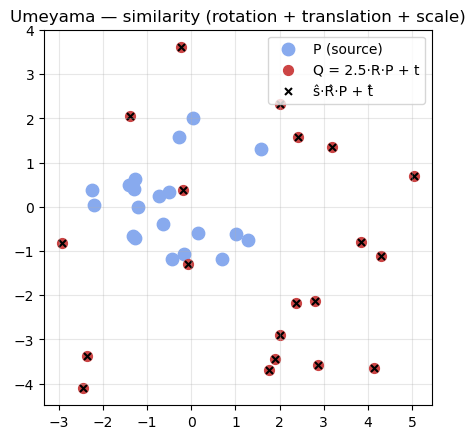

In [5]:
def umeyama(P, Q):
    """Similarity transform (s, R, t) minimising Σ ‖qᵢ - (s R pᵢ + t)‖²."""
    n, d = P.shape
    p_bar = P.mean(axis=0)
    q_bar = Q.mean(axis=0)
    Pc = P - p_bar
    Qc = Q - q_bar
    Sigma_pq = (Qc.T @ Pc) / n
    sigma_p2 = (Pc * Pc).sum() / n
    U, D, Vt = np.linalg.svd(Sigma_pq)
    S = np.eye(d)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    s = (D * np.diag(S)).sum() / sigma_p2
    t = q_bar - s * R @ p_bar
    return s, R, t

s_true = 2.5
Q_scaled = s_true * (P @ R_true.T) + t_true
s_hat, R_hat, t_hat = umeyama(P, Q_scaled)
print(f"Umeyama     ŝ = {s_hat:.4f} (true {s_true})  "
      f"‖R̂ - R‖ = {np.linalg.norm(R_hat - R_true):.2e}  "
      f"‖t̂ - t‖ = {np.linalg.norm(t_hat - t_true):.2e}")

fig, ax = plt.subplots(figsize=(5, 5))
Pt = s_hat * (P @ R_hat.T) + t_hat
ax.scatter(P[:, 0],         P[:, 1],         s=80, c='#88aaee', label='P (source)')
ax.scatter(Q_scaled[:, 0],  Q_scaled[:, 1],  s=50, c='#cc4444', label=f'Q = {s_true}·R·P + t')
ax.scatter(Pt[:, 0],        Pt[:, 1],        s=25, c='black', marker='x', label='ŝ·R̂·P + t̂')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Umeyama — similarity (rotation + translation + scale)')
plt.show()

## 6. Iterative Closest Point (ICP)

**Problem.** Same goal as Kabsch — align $P$ onto $Q$ — but the correspondences are **not given**. The two clouds may even have different sizes ($n \ne m$).

$$
(R^{\star}, \mathbf{t}^{\star}) \;=\; \arg\min_{R,\, \mathbf{t}} \; \sum_{\mathbf{p}_i \in P} \min_{\mathbf{q}_j \in Q} \lVert \mathbf{q}_j - (R\,\mathbf{p}_i + \mathbf{t}) \rVert^2.
$$

**Algorithm.** Alternate two steps:

1. **Data association** — for each $\mathbf{p}_i$, find the closest $\mathbf{q}_j$ in the *current* aligned cloud (typically a kd-tree query).
2. **Transform refinement** — solve the resulting Procrustes/Kabsch problem on those correspondences, update $(R, \mathbf{t})$.

Repeat until $(R, \mathbf{t})$ stops changing (or the mean residual stabilises). Each iteration monotonically decreases the cost, but ICP only finds a **local minimum** — initialisation matters. Practical variants address this with point-to-plane cost, robust kernels (Huber, Tukey), normal-shooting, multi-resolution downsampling, etc.

ICP is the workhorse of LiDAR SLAM, depth-camera registration, and 3D scan stitching.

**Where this shows up — LiDAR odometry on a self-driving car.** A roof-mounted Velodyne or Ouster LiDAR captures a 3D scan of the surroundings every 100 ms. You don't know which point in scan $t+1$ corresponds to which point in scan $t$ — the car has moved, the laser has spun, points are sampled from different parts of nearby surfaces. ICP (or one of its many descendants — generalised ICP, point-to-plane, KISS-ICP) registers each new scan to a local map and reports the rigid motion between scans; integrate the per-frame transforms and you have **LiDAR odometry**, the backbone of the LOAM family of SLAM systems and most production AV stacks. The motion between consecutive scans is small enough that identity-initialisation (or the previous frame's velocity) reliably falls inside ICP's basin of convergence.

**Worked example — by hand (one ICP iteration, correspondences unknown).** Two 2D clouds, with **no** given pairing. Source and (shuffled) target:

$$P=\{(0,0),(3,0),(0,3)\},\qquad Q=\{(3.5,0.2),(0.5,3.2),(0.5,0.2)\}$$

($Q$ is $P$ shifted by $(0.5,0.2)$ and then reordered — we are *not* told which point maps to which).

**Step 1 — data association** (nearest neighbour, from the identity guess). For each $p$, take the closest $q$:

- $(0,0)$: distances $3.51,\ 3.24,\ 0.54$ → nearest $(0.5,0.2)$
- $(3,0)$: nearest $(3.5,0.2)$ (distance $0.54$)
- $(0,3)$: nearest $(0.5,3.2)$ (distance $0.54$)

All three pair correctly. **Step 2 — Kabsch on those pairs:** the recovered pairing is a pure translation, so $R=I$ and $\mathbf t=(0.5,0.2)$. Re-running association finds the same pairs, nothing changes → **converged in one iteration**.

The caveat that *defines* ICP: had the shift exceeded the point spacing, the nearest-neighbour step would have mis-paired the points, Kabsch would return the wrong transform, and the loop could settle into a **local** minimum. That sensitivity to the initial guess is the whole practical story of ICP.


ICP         ‖R̂ - R‖ = 4.059767698617113e-16   ‖t̂ - t‖ = 3.2494477869482716e-16   iterations = 4


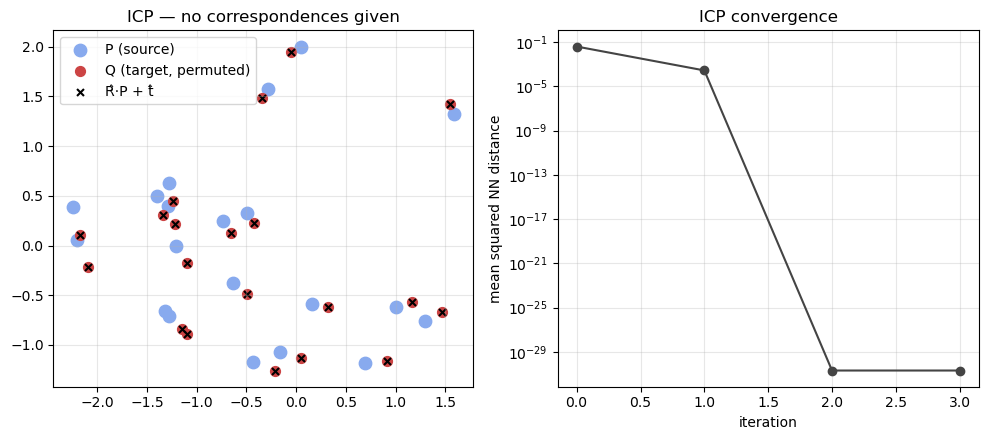

In [6]:
from scipy.spatial import cKDTree

def icp(P, Q, max_iter=50, tol=1e-6):
    """Returns (R, t, history) aligning P onto Q. Identity initialisation."""
    tree = cKDTree(Q)
    R = np.eye(3)
    t = np.zeros(3)
    history = []
    prev_err = np.inf
    for _ in range(max_iter):
        Pt = P @ R.T + t                  # current pose
        d, idx = tree.query(Pt)           # nearest target points
        R, t = kabsch(P, Q[idx])          # closed-form refinement
        err = (d ** 2).mean()
        history.append(err)
        if abs(prev_err - err) < tol:
            break
        prev_err = err
    return R, t, history

# ICP only converges from identity when the misalignment is small enough that
# initial nearest-neighbour matches are mostly correct. Use a ~6° rotation.
theta = 0.1
R_small = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0],
])
t_small = np.array([0.1, -0.05, 0.0])
Q_small = P @ R_small.T + t_small

# Shuffle to break the trivial 1:1 row correspondence.
perm = rng.permutation(len(Q_small))
R_hat, t_hat, hist = icp(P, Q_small[perm])
print("ICP         ‖R̂ - R‖ =", np.linalg.norm(R_hat - R_small),
      "  ‖t̂ - t‖ =", np.linalg.norm(t_hat - t_small),
      "  iterations =", len(hist))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
Pt = P @ R_hat.T + t_hat
ax1.scatter(P[:, 0],  P[:, 1],  s=80, c='#88aaee', label='P (source)')
ax1.scatter(Q_small[perm, 0], Q_small[perm, 1], s=50, c='#cc4444', label='Q (target, permuted)')
ax1.scatter(Pt[:, 0], Pt[:, 1], s=25, c='black', marker='x', label='R̂·P + t̂')
ax1.set_aspect('equal'); ax1.grid(alpha=0.3); ax1.legend()
ax1.set_title('ICP — no correspondences given')

ax2.semilogy(hist, 'o-', c='#444')
ax2.set_xlabel('iteration'); ax2.set_ylabel('mean squared NN distance')
ax2.grid(alpha=0.3); ax2.set_title('ICP convergence')
plt.tight_layout(); plt.show()

## The single problem underneath — $\max\ \operatorname{tr}(R^\top M)$ and projection onto $SO(3)$

Every closed-form solver above is the *same* optimisation. Expanding any of the costs, the rotation-dependent part collapses to one trace:

$$\min_{R}\ \lVert B-RA\rVert_F^2 \;\;\Longleftrightarrow\;\; \max_{R}\ \operatorname{tr}(R^\top M),\qquad M=\textstyle\sum_i w_i\,\mathbf b_i\mathbf a_i^\top \;=\; BA^\top .$$

They differ only in **what $M$ is** and **which constraint set $R$ lives in**:

| solver | $M$ | extra machinery |
|---|---|---|
| Procrustes | $BA^\top$ | — (allows $O(d)$ unless det-fixed) |
| Wahba | $\sum_i w_i\,\mathbf b_i\mathbf a_i^\top$ | per-pair weights, unit vectors, $SO(3)$ |
| Kabsch | $\tilde P^\top\tilde Q$ (**centred**) | centring removes translation |
| Umeyama | centred $\Sigma_{pq}$ | one scalar $s=\operatorname{tr}(DS)/\sigma_p^2$ |
| Davenport / QUEST | same profile as Wahba | solved as a $4\times4$ eigenproblem in quaternion space |

### Wahba vs Procrustes — and does normalising make them identical?

Wahba **is** orthogonal Procrustes, specialised to 3D, unit-vector data, per-pair weights, and the $\det=+1$ constraint. Two subtleties about "just normalise the input":

- **Normalising reweights, it is not a no-op.** In Procrustes each point enters the Frobenius cost with weight $\propto$ its magnitude$^2$, so a far point dominates the fit. Rescaling every vector to unit length makes all directions count equally — exactly *unweighted* Wahba. With **noise-free** data $R$ is identical either way; with **noise** you get a *different* $R$ because you changed the error weighting. That is the real difference between the two.
- **Normalising removes scale, not translation.** Both Procrustes and Wahba assume *no translation* (a direction has no position). Unit-normalising does **not** centre the data — translation is removed by *centring* (that is precisely what Kabsch adds), not by normalisation.

### With noise, how do we land in $SO(3)$ and not just some $3\times3$ matrix?

Under noise $M$ is a *general* $3\times3$ matrix — **not** orthogonal — so you never read $R$ off directly. The SVD **is** the projection of $M$ onto the rotation manifold: since $\lVert R-M\rVert_F^2=3+\lVert M\rVert_F^2-2\operatorname{tr}(R^\top M)$, minimising $\lVert R-M\rVert_F$ equals maximising $\operatorname{tr}(R^\top M)$. With $M=U\Sigma V^\top$ and $Z=U^\top R V$ (orthogonal),

$$\operatorname{tr}(R^\top M)=\operatorname{tr}(Z^\top\Sigma)=\sum_i z_{ii}\,\sigma_i\ \le\ \sum_i\sigma_i,\qquad |z_{ii}|\le 1,$$

maximised at $Z=I$, i.e. $R=UV^\top$ — the **orthogonal polar factor** of $M$ (polar decomposition $M=R\,P$, $P=V\Sigma V^\top\succeq0$). So "get $R\in SO(3)$" literally means *take the polar factor*, and the SVD gives it in closed form.

The **det-correction** enforces a *proper* rotation rather than a reflection: if $\det(UV^\top)=-1$, then $Z=I$ is a reflection (and a noisy $M$ can make that reflection cheaper than any rotation). The best proper choice flips the sign on the *smallest* singular value's axis,

$$R^\star=U\,\operatorname{diag}\!\bigl(1,1,\det(UV^\top)\bigr)\,V^\top,$$

paying only $\sigma_{\min}$ (the least-supported direction) to stay in $SO(3)$. This is the identical operation used in §1 to re-orthonormalise a drifted rotation.

**The quaternion route avoids the fix entirely.** Davenport/QUEST parameterise $R$ by a unit quaternion $q\in S^3$; every unit quaternion maps to a *proper* rotation and reflections are not representable, so the top-eigenvector solution is automatically in $SO(3)$ — the constraint is baked into the parameterisation instead of corrected after the fact.


### Is $R\in SO(3)$ guaranteed under noise? Yes — by construction

The output is a valid proper rotation for *any* input, no matter how noisy, and this holds by construction rather than by luck. Two facts stack up:

1. **The SVD always yields orthogonal $U$ and $V$** — a property of the SVD for *any* real matrix $M$, however non-orthogonal. A product of orthogonal matrices is orthogonal, so $UV^\top\in O(3)$ *exactly*. Noise cannot break this; it only changes *which* orthogonal matrix appears and makes the residual $\lVert B-RA\rVert$ non-zero.
2. **The det-correction upgrades $O(3)\to SO(3)$.** Plain $UV^\top$ is guaranteed orthogonal but may have $\det=-1$ (a reflection); the factor $\operatorname{diag}(1,1,\det(UV^\top))$ forces $\det=+1$, a *proper* rotation.

Hence $R=U\operatorname{diag}(1,1,\det(UV^\top))V^\top\in SO(3)$ for any input whatsoever — noise changes the *accuracy* of $R$ and the size of the residual, never its membership in $SO(3)$.

**Caveat — uniqueness, not validity.** If the data is *degenerate* (collinear points, or a zero/tied singular value), $R$ is still a valid rotation but may no longer be *unique* (a family of rotations achieves the same cost). With generic noisy data $M$ has full rank and distinct singular values, so the solution is both in $SO(3)$ and unique.

**Contrast — why the SVD and not Gram–Schmidt.** Naively re-orthonormalising $M$ by Gram–Schmidt also returns *an* orthogonal matrix, but not the *closest* one, and in an order-dependent way. The SVD returns the closest rotation (the orthogonal polar factor) in one shot — that is why it is the right tool.


## Comparison — technical

| Algorithm | Inputs | Output | Correspondences | Closed form? | Solution method | Domain |
|---|---|---|---|---|---|---|
| **Orthogonal Procrustes** | $A, B \in \mathbb{R}^{d \times n}$ | $R \in O(d)$ (or $SO(d)$) | known | yes | SVD of $B A^\top$ | general $d$-dim |
| **Wahba** | unit vectors $\{(\mathbf{a}_i, \mathbf{b}_i)\}$, weights $w_i$ | $R \in SO(3)$ | known | yes | SVD of profile + det correction | spacecraft / UAV attitude |
| **q-method / QUEST** | same as Wahba | quaternion $q \in S^3$ | known | yes (eig); QUEST: Newton on the secular equation | largest eigenvalue of Davenport's $4\times 4$ matrix $K$ | flight-grade onboard attitude |
| **Kabsch** | $P, Q \in \mathbb{R}^{n \times 3}$ | $R \in SO(3),\ \mathbf{t}$ | known | yes | centred SVD | rigid 3D-3D registration, SLAM loop closure |
| **Umeyama** | $P, Q \in \mathbb{R}^{n \times d}$ | $s, R, \mathbf{t}$ (similarity) | known | yes | centred SVD + scale formula | monocular SLAM trajectory evaluation |
| **ICP** | $P, Q$ (sizes may differ) | $R, \mathbf{t}$ | **unknown — discovered iteratively** | no | nearest-neighbour + Kabsch per iteration | LiDAR / RGB-D scan registration |

## Comparison — one concrete robotics application per algorithm

| Algorithm | Where you actually run into this |
|---|---|
| **Orthogonal Procrustes** | Re-orthonormalising a drifted 3×3 rotation matrix inside an EKF or pose integrator (`B = R, A = I` → SVD → nearest $SO(3)$); same trick repairs rotations regressed by a neural network |
| **Wahba** | Bootstrap attitude for a UAV / quadcopter on the ground: gravity (accelerometer) and Earth's B-field (magnetometer + WMM model) as the two reference vectors; same setup initialises a CubeSat from sun-sensor + magnetometer measurements |
| **q-method / QUEST** | Onboard attitude estimator on flight hardware — spacecraft star trackers since NASA Magsat (1979), and PX4/ArduPilot's quaternion EKF initialiser at boot on a 168 MHz STM32F4 |
| **Kabsch** | Loop closure in RGB-D / stereo SLAM — Kabsch on matched 3D-3D feature pairs gives the relative pose between two keyframes, which becomes a constraint added to the pose graph (g2o / GTSAM) |
| **Umeyama** | `evo_ape -as` aligning a monocular ORB-SLAM3 trajectory to motion-capture ground truth on TUM-RGBD / EuRoC (the `-as` flag = "with scale" — monocular has unobservable scale) |
| **ICP** | LiDAR odometry on a self-driving car or a quadruped: register each new Velodyne / Ouster / Livox scan to the previous one (or to a local map) at 10 Hz — the backbone of LOAM, KISS-ICP, FAST-LIO, and most production AV stacks |

## Bottom line

Procrustes and Wahba are the same problem in different notation — Wahba is just Procrustes with the convention of "unit-vector observations" and the additional $SO(3)$ constraint. Kabsch is Procrustes lifted to point clouds with translation. Umeyama is Kabsch with a scale. q-method/QUEST swap the SVD for an eigenvalue formulation — same answer, different machinery. ICP wraps Kabsch in an outer loop to handle the case where you don't know which point matches which.

---

References:

- Schoenemann (1966), *A generalized solution of the orthogonal procrustes problem*.
- Wahba (1965), *A least squares estimate of satellite attitude*, SIAM Review.
- Shuster & Oh (1981), *Three-axis attitude determination from vector observations* (QUEST).
- Kabsch (1976), *A solution for the best rotation to relate two sets of vectors*, Acta Cryst.
- Umeyama (1991), *Least-squares estimation of transformation parameters between two point patterns*, IEEE PAMI.
- Besl & McKay (1992), *A method for registration of 3-D shapes*, IEEE PAMI (ICP).